## Observation Gap Dectection

### Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load dataset and convert time

In [ ]:
df = pd.read_csv("/content/sylhet_aman_observations_classified.csv")

df['date'] = pd.to_datetime(df['date'])
df = (df.sort_values('date').reset_index(drop=True))

### Validity Threshold

In [ ]:
VALID_THRESHOLDS = [50, 60, 70, 80, 90]

### Function to calculate within-season gaps

In [ ]:
def calculate_within_season_gaps(data, threshold):

    all_year_gap_tables = []
    all_year_valid_dates = []
    yearly_summary = []


    # Loop through each Aman season

    for year in sorted(data["year"].unique()):

        # 1. Select only this year's observations

        season = data[
            data["year"] == year
        ].copy()

        # Sort observations chronologically
        season = (
            season
            .sort_values("date")
            .reset_index(drop=True)
        )

        # 2. Keep only observations satisfying the threshold


        valid = season[
            season[f"valid_{threshold}"] == True
        ].copy()


        # 3. Keep unique VALID observation dates
        # Sentinel-2A and Sentinel-2C can sometimes observe

        valid_dates = (
            valid[
                ["date", "year"]
            ]
            .drop_duplicates()
            .sort_values("date")
            .reset_index(drop=True)
        )


        # 4. Calculate interval between consecutive VALID observation dates

        valid_dates["interval_days"] = (
            valid_dates["date"].diff().dt.days
        )


        # 5. Store the previous valid observation date, maybe need in reporting
        valid_dates["previous_valid_date"] = (
            valid_dates["date"].shift(1)
        )


        # 6. Remove the first observation
        gap_table = valid_dates[
            valid_dates["interval_days"].notna()
        ].copy()


        # 7. Record which threshold was used
        gap_table["threshold"] = threshold


        # 8. Store this year's gap table
        all_year_gap_tables.append(
            gap_table
        )

        # 9.Store this year's valid dates
        all_year_valid_dates.append(
            valid_dates
        )


        # 9. Calculate summary statistics for this year
        intervals = gap_table[
            "interval_days"
        ]

        if len(intervals) > 0:

            mean_interval = intervals.mean()
            median_interval = intervals.median()
            maximum_interval = intervals.max()
            minimum_interval = intervals.min()

        else:

            mean_interval = np.nan
            median_interval = np.nan
            maximum_interval = np.nan
            minimum_interval = np.nan

        yearly_summary.append({

            "year": year,

            "threshold": threshold,

            "valid_dates":
                len(valid_dates),

            "number_of_intervals":
                len(intervals),

            "mean_interval_days":
                mean_interval,

            "median_interval_days":
                median_interval,

            "maximum_interval_days":
                maximum_interval,

            "minimum_interval_days":
                minimum_interval

        })


    # 10. Combine gap tables from all years

    if len(all_year_gap_tables) > 0:

        combined_gap_table = pd.concat(
            all_year_gap_tables,
            ignore_index=True
        )

    else:

        combined_gap_table = pd.DataFrame()


    # 11. Combine valid observation dates from all years

    if len(all_year_valid_dates) > 0:

        combined_valid_dates = pd.concat(
            all_year_valid_dates,
            ignore_index=True
        )

    else:

        combined_valid_dates = pd.DataFrame()


    # 12. Convert yearly summaries into a DataFrame

    yearly_summary = pd.DataFrame(
        yearly_summary
    )


    # 13. Return the three outputs

    return (
        combined_gap_table,
        combined_valid_dates,
        yearly_summary
    )

### Run Gap Analysis For All Threshold

In [ ]:
all_gap_tables = {}

all_valid_dates = {}

all_yearly_summaries = {}


for threshold in VALID_THRESHOLDS:

    (
        gap_table,
        valid_dates,
        yearly_summary
    ) = calculate_within_season_gaps(
        df,
        threshold
    )


    all_gap_tables[threshold] = gap_table

    all_valid_dates[threshold] = valid_dates

    all_yearly_summaries[threshold] = yearly_summary


### Combine Yearly Summary

In [ ]:
yearly_gap_summary = pd.concat(
    all_yearly_summaries.values(),
    ignore_index=True
)


print("\n============================================================")
print("WITHIN-SEASON YEARLY GAP SUMMARY")
print("============================================================")


print(
    yearly_gap_summary.round(2)
)



WITHIN-SEASON YEARLY GAP SUMMARY
    year  threshold  valid_dates  number_of_intervals  mean_interval_days  \
0   2022         50           19                   18                9.44   
1   2023         50           13                   12               17.08   
2   2024         50           15                   14                8.57   
3   2022         60           18                   17               10.00   
4   2023         60           13                   12               17.08   
5   2024         60           14                   13                8.85   
6   2022         70           17                   16               10.62   
7   2023         70           13                   12               17.08   
8   2024         70           12                   11               10.45   
9   2022         80           16                   15               11.33   
10  2023         80           12                   11               18.64   
11  2024         80           10          

### Overall Gap Summary

In [ ]:
overall_results = []


for threshold in VALID_THRESHOLDS:

    gap_table = all_gap_tables[threshold]


    if len(gap_table) > 0:

        intervals = gap_table[
            "interval_days"
        ]

        overall_results.append({

            "threshold":
                threshold,

            "total_within_season_intervals":
                len(intervals),

            "mean_interval_days":
                intervals.mean(),

            "median_interval_days":
                intervals.median(),

            "maximum_interval_days":
                intervals.max(),

            "minimum_interval_days":
                intervals.min()

        })


    else:

        overall_results.append({

            "threshold":
                threshold,

            "total_within_season_intervals":
                0,

            "mean_interval_days":
                np.nan,

            "median_interval_days":
                np.nan,

            "maximum_interval_days":
                np.nan,

            "minimum_interval_days":
                np.nan

        })


overall_gap_summary = pd.DataFrame(
    overall_results
)


print("\n============================================================")
print("OVERALL WITHIN-SEASON GAP SUMMARY")
print("============================================================")


print(
    overall_gap_summary.round(2)
)


OVERALL WITHIN-SEASON GAP SUMMARY
   threshold  total_within_season_intervals  mean_interval_days  \
0         50                             44               11.25   
1         60                             42               11.67   
2         70                             39               12.56   
3         80                             35               14.00   
4         90                             29               15.34   

   median_interval_days  maximum_interval_days  minimum_interval_days  
0                   5.0                   55.0                    5.0  
1                   5.0                   55.0                    5.0  
2                  10.0                   55.0                    5.0  
3                  10.0                   55.0                    5.0  
4                  10.0                   90.0                    5.0  


## Find the leargest within-season interval

In [ ]:
print("\n============================================================")
print("LARGEST WITHIN-SEASON OBSERVATION INTERVAL")
print("============================================================")


largest_gap_records = []


for threshold in VALID_THRESHOLDS:

    gap_table = all_gap_tables[threshold]


    if len(gap_table) == 0:

        continue


    largest_index = (
        gap_table["interval_days"]
        .idxmax()
    )


    largest = gap_table.loc[
        largest_index
    ]


    largest_gap_records.append({

        "threshold":
            threshold,

        "year":
            int(largest["year"]),

        "previous_valid_date":
            largest["previous_valid_date"],

        "next_valid_date":
            largest["date"],

        "interval_days":
            largest["interval_days"]

    })


largest_gap_summary = pd.DataFrame(
    largest_gap_records
)


print(
    largest_gap_summary.round(2)
)



LARGEST WITHIN-SEASON OBSERVATION INTERVAL
   threshold  year previous_valid_date next_valid_date  interval_days
0         50  2023          2023-06-05      2023-07-30           55.0
1         60  2023          2023-06-05      2023-07-30           55.0
2         70  2023          2023-06-05      2023-07-30           55.0
3         80  2023          2023-06-05      2023-07-30           55.0
4         90  2023          2023-06-05      2023-09-03           90.0


## Gap Distribution

In [ ]:
GAP_BINS = [
    0,
    5,
    10,
    15,
    20,
    30,
    np.inf
]


GAP_LABELS = [
    "≤5 days",
    "6–10 days",
    "11–15 days",
    "16–20 days",
    "21–30 days",
    ">30 days"
]


distribution_results = []


for threshold in VALID_THRESHOLDS:

    gap_table = all_gap_tables[threshold]


    if len(gap_table) == 0: #defence

        continue


    categories = pd.cut(                          #heart of the code

        gap_table["interval_days"],

        bins=GAP_BINS,

        labels=GAP_LABELS,

        include_lowest=True

    )


    counts = (

        categories

        .value_counts()

        .reindex(
            GAP_LABELS,
            fill_value=0
        )

    )


    for label, count in counts.items():

        distribution_results.append({

            "threshold":
                threshold,

            "gap_category":
                label,

            "count":
                count

        })


gap_distribution = pd.DataFrame(
    distribution_results
)


print("\n============================================================")
print("WITHIN-SEASON GAP DISTRIBUTION")
print("============================================================")


print(
    gap_distribution
)


WITHIN-SEASON GAP DISTRIBUTION
    threshold gap_category  count
0          50      ≤5 days     25
1          50    6–10 days      7
2          50   11–15 days      3
3          50   16–20 days      4
4          50   21–30 days      3
5          50     >30 days      2
6          60      ≤5 days     22
7          60    6–10 days      8
8          60   11–15 days      3
9          60   16–20 days      4
10         60   21–30 days      3
11         60     >30 days      2
12         70      ≤5 days     19
13         70    6–10 days      8
14         70   11–15 days      1
15         70   16–20 days      5
16         70   21–30 days      4
17         70     >30 days      2
18         80      ≤5 days     16
19         80    6–10 days      7
20         80   11–15 days      2
21         80   16–20 days      3
22         80   21–30 days      3
23         80     >30 days      4
24         90      ≤5 days     13
25         90    6–10 days      7
26         90   11–15 days      1
27         90   

# Gap distribution acroos all validity thresholds

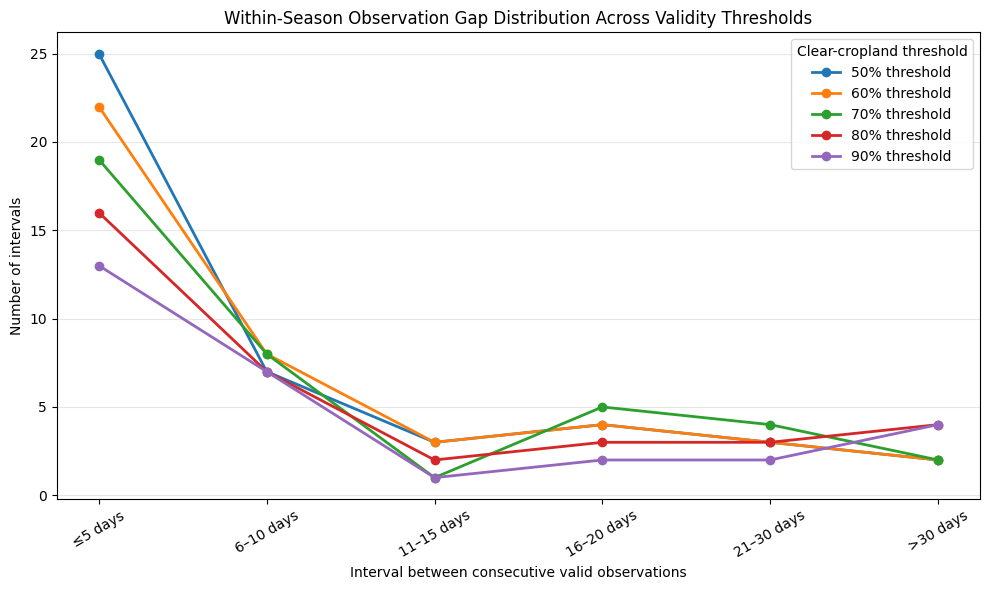

In [ ]:
gap_distribution_pivot = gap_distribution.pivot(
    index="gap_category",
    columns="threshold",
    values="count"
)

# Keep the categories in the correct chronological order

gap_distribution_pivot = gap_distribution_pivot.reindex(
    GAP_LABELS
)


plt.figure(figsize=(10, 6))


for threshold in VALID_THRESHOLDS:

    if threshold in gap_distribution_pivot.columns:

        plt.plot(
            gap_distribution_pivot.index,
            gap_distribution_pivot[threshold],
            marker="o",
            linewidth=2,
            label=f"{threshold}% threshold"
        )


plt.xlabel(
    "Interval between consecutive valid observations"
)

plt.ylabel(
    "Number of intervals"
)

plt.title(
    "Within-Season Observation Gap Distribution "
    "Across Validity Thresholds"
)

plt.legend(
    title="Clear-cropland threshold"
)

plt.xticks(
    rotation=30
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

## Save final results

In [ ]:
overall_gap_summary.to_csv(
    "03_overall_within_season_gap_summary.csv",
    index=False
)

yearly_gap_summary.to_csv(
    "03_yearly_within_season_gap_summary.csv",
    index=False
)

largest_gap_summary.to_csv(
    "03_largest_within_season_intervals.csv",
    index=False
)

gap_distribution.to_csv(
    "03_within_season_gap_distribution.csv",
    index=False
)